<div class='module-banner'>
<p class='module-banner-kicker'>FARMSA Portfolio Theory | Module 2</p>
<h1>RMT Eigenvalue Cleaning</h1>
<p class='module-banner-sub'>Eigenvalue denoising using a random-matrix noise boundary.</p>
<p class='module-banner-author'>Author: Pranay</p>
</div>


## RMT Eigenvalue Cleaning

### The Problem with Sample Covariance

we are using $N = 50$ stocks estimated from $T = 1{,}759$ days. The sample covariance matrix contains $\frac{N(N+1)}{2} = 1{,}275$ unique parameters, all estimated from the same data. The ratio $q = N/T \approx 0.028$ means we have roughly **35 observations per parameter**, which sounds adequate but isn't — most of the off-diagonal structure is pure estimation noise.

The consequence for portfolio optimization: the optimizer sees spurious correlations as real, takes positions that exploit them, and underperforms out-of-sample.

### The Marchenko–Pastur Law

In 1967, Marchenko and Pastur proved that if you fill an $N \times T$ matrix with **pure i.i.d. noise** and compute its covariance matrix, the eigenvalues follow a specific distribution with support:

$$
\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{q}\right)^2, \qquad q = \frac{N}{T}
$$

where $\sigma^2$ is the noise variance. This gives us a **noise ceiling** $\lambda_+$: any eigenvalue below it is statistically indistinguishable from pure noise.

### The Cleaning Algorithm

1. Eigendecompose the sample covariance: $\hat{\Sigma} = V \, \text{diag}(\lambda) \, V^\top$
2. Estimate the noise level: $\sigma^2 = \frac{1}{N}\sum_i \lambda_i$ (mean eigenvalue)
3. Compute the MP upper bound $\lambda_+$
4. Identify signal eigenvalues ($\lambda_i > \lambda_+$) and noise eigenvalues ($\lambda_i \leq \lambda_+$)
5. Replace all noise eigenvalues with their mean $\bar{\lambda}_{\text{noise}}$ — this preserves the matrix trace (total variance)
6. Reconstruct:

$$
\hat{\Sigma}_{\text{clean}} = \sum_{i \in \text{signal}} \lambda_i \, v_i v_i^\top \;+\; \bar{\lambda}_{\text{noise}} \sum_{i \in \text{noise}} v_i v_i^\top
$$

### Why Replace With the Mean (Not Zero)?

Setting noise eigenvalues to zero would destroy total variance (the trace of the matrix). Replacing with their mean $\bar{\lambda}_{\text{noise}}$ redistributes that variance uniformly across noise directions the covariance in those directions is neither inflated (as in the raw matrix) nor eliminated, just neutralised.

In [1]:
# ── §2  Setup & Estimator ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

prices  = pd.read_csv('data/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)
N, T = returns.shape[1], returns.shape[0]
print(f"Loaded {N} assets × {T} days  |  q = N/T = {N/T:.4f}")

Loaded 50 assets × 1759 days  |  q = N/T = 0.0284


In [2]:

def estimate_covariance(returns_df):
    """Return an N×N covariance matrix using RMT Eigenvalue Cleaning."""
    """
    RMT-cleaned covariance matrix using Marchenko-Pastur eigenvalue cleaning.

    Steps USed here are
      1. First Compute sample covariance
      2. then Eigendecompose it
      3. thrid Estimate noise level sigma^2 = mean of all eigenvalues
      4. Compute MP upper bound lambda_plus
      5. Replace noise eigenvalues (below lambda_plus) with their mean
      6. Reconstruct the cleaned matrix

    Input:  returns_df  (pd.DataFrame, T x N daily returns)
    Output: N x N numpy array (symmetric, positive semi-definite)
    """
    T_win, N_assets = returns_df.shape
    q = N_assets / T_win

    S = returns_df.cov().values

    # Eigendecomposed  (eigh is used since we have a 50x50 matrix, symetric so faster w this
    eigenvalues, eigenvectors = np.linalg.eigh(S)

    # Sorted descending, big eign first
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Estimate noise variancem wwhuch would be the mean of all eigenvalues
    mean = np.mean(eigenvalues)

    #Marchenko-Pastur upper bound, 
    #so this is the bound we use to determine eigenvalues/correlations that are just noise
    #anything less than this bound is noise, anything above is signal
    lambda_plus = mean * (1 + np.sqrt(q))**2

    signal_mask = eigenvalues > lambda_plus
    noise_mask  = ~signal_mask

    # replaced the noise 
    # eigenvalues with their mean here
    cleaned_eigenvalues = eigenvalues.copy()
    if noise_mask.sum() > 0:
        cleaned_eigenvalues[noise_mask] = eigenvalues[noise_mask].mean()

    V = eigenvectors
    cleaned_cov = V @ np.diag(cleaned_eigenvalues) @ V.T

    cleaned_cov = (cleaned_cov + cleaned_cov.T) / 2

    return cleaned_cov


cov_test = estimate_covariance(returns.iloc[:252])
assert cov_test.shape == (N, N), f"Expected ({N},{N}), got {cov_test.shape}"
assert np.allclose(cov_test, cov_test.T), "Not symmetric"
assert np.all(np.linalg.eigvalsh(cov_test) > -1e-10), "Negative eigenvalues"
print("✓ Estimator passes sanity checks")

✓ Estimator passes sanity checks


In [3]:
# ── §3  Eigenvalue Cleaning Diagnostics ───────────────────
#here are some ways we can see what cleaning actually does to the spectrum
#Not a performance measure of the system above, j a way to see how cleaning works

#using full sample(uncleaned) as referce
S_full = returns.cov().values
q_full = N / T

raw_eigenvalues, eigenvectors_full = np.linalg.eigh(S_full)
idx = np.argsort(raw_eigenvalues)[::-1]
raw_eigenvalues = raw_eigenvalues[idx]
eigenvectors_full = eigenvectors_full[:, idx]

sigma_sq_full = np.mean(raw_eigenvalues)
lambda_plus_full = sigma_sq_full * (1 + np.sqrt(q_full))**2

signal_mask_full = raw_eigenvalues > lambda_plus_full
noise_mask_full = ~signal_mask_full
n_signal = signal_mask_full.sum()
n_noise = noise_mask_full.sum()

cleaned_eigenvalues_full = raw_eigenvalues.copy()
noise_mean = raw_eigenvalues[noise_mask_full].mean()
cleaned_eigenvalues_full[noise_mask_full] = noise_mean



#what this tells us
# q : how noisy our setup is (more assets vs days = higher q = more noise)
# sigma^2 : our estimate of the background noise level in the data
# lambda+ : the cutoff: any eigenvalue below this is indistinguishable from pure noise

# Signal eigenvalues : the few components that have actual/real/important covariance info
# Noise eigenvalues : the majority that are just estimation noise, get replaced
# Noise mean    : the single value all noise eigenvalues get replaced with

print(f"q = N/T = {q_full:.4f}")
print(f"sigma^2 (noise estimate) = {sigma_sq_full:.6f}")
print(f"MP upper bound lambda+ = {lambda_plus_full:.6f}")
print(f" ")
print(f"Signal eigenvalues : {n_signal:>3d}  ({n_signal/N*100:.0f}% of spectrum)")
print(f"Noise eigenvalues  : {n_noise:>3d}  ({n_noise/N*100:.0f}% of spectrum)")
print(f"Noise mean (replacement value) = {noise_mean:.6f}")


q = N/T = 0.0284
sigma^2 (noise estimate) = 0.000385
MP upper bound lambda+ = 0.000526
 
Signal eigenvalues :   4  (8% of spectrum)
Noise eigenvalues  :  46  (92% of spectrum)
Noise mean (replacement value) = 0.000161


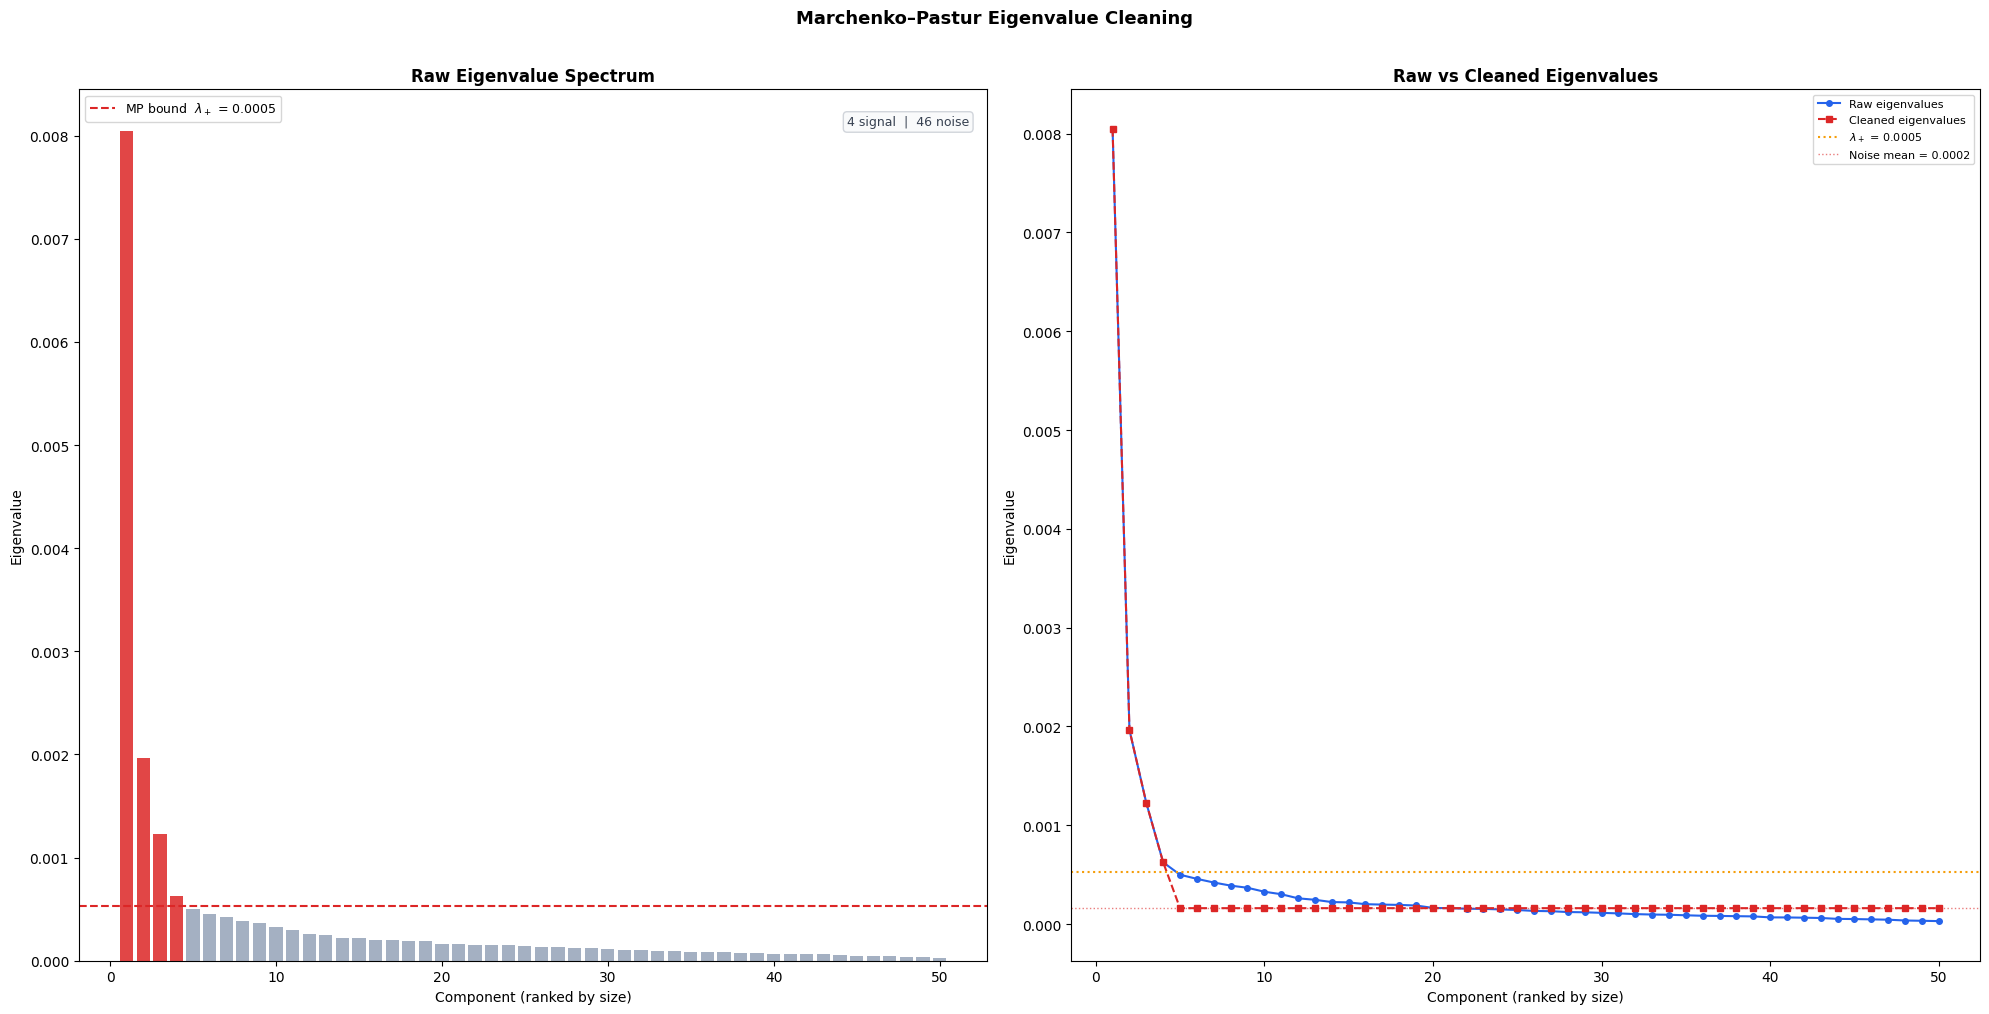

In [4]:
# ── §4  Visualisation 1: Eigenvalue Spectrum ──────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

#Left axis being the raw spectrum
#So we'll see a handful of the important eigenvalues as tall red bars
#Dashed line showing the cutoff for noise

ax = axes[0]
colors = ['#dc2626' if v else '#94a3b8' for v in signal_mask_full]
ax.bar(range(1, N+1), raw_eigenvalues, color=colors, alpha=0.85, width=0.8)
ax.axhline(lambda_plus_full, color='#dc2626', linestyle='--', lw=1.5,
           label=f'MP bound  $\\lambda_+$ = {lambda_plus_full:.4f}')
ax.set_xlabel('Component (ranked by size)')
ax.set_ylabel('Eigenvalue')
ax.set_title('Raw Eigenvalue Spectrum', fontweight='bold')
ax.legend(fontsize=9)
ax.text(0.98, 0.97, f'{n_signal} signal  |  {n_noise} noise',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='#374151',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9fafb', edgecolor='#d1d5db'))

# Right plot
#The signal/important eigenvalues are left untouched, but the noise is all flattened out
ax2 = axes[1]
x = np.arange(1, N+1)
ax2.plot(x, raw_eigenvalues,     'o-', color='#2563eb', lw=1.5, ms=4, label='Raw eigenvalues')
ax2.plot(x, cleaned_eigenvalues_full, 's--', color='#dc2626', lw=1.5, ms=4, label='Cleaned eigenvalues')
ax2.axhline(lambda_plus_full, color='#f59e0b', linestyle=':', lw=1.5, label=f'$\\lambda_+$ = {lambda_plus_full:.4f}')
ax2.axhline(noise_mean, color='#dc2626', linestyle=':', lw=1.0, alpha=0.6, label=f'Noise mean = {noise_mean:.4f}')
ax2.set_xlabel('Component (ranked by size)')
ax2.set_ylabel('Eigenvalue')
ax2.set_title('Raw vs Cleaned Eigenvalues', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Marchenko–Pastur Eigenvalue Cleaning', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

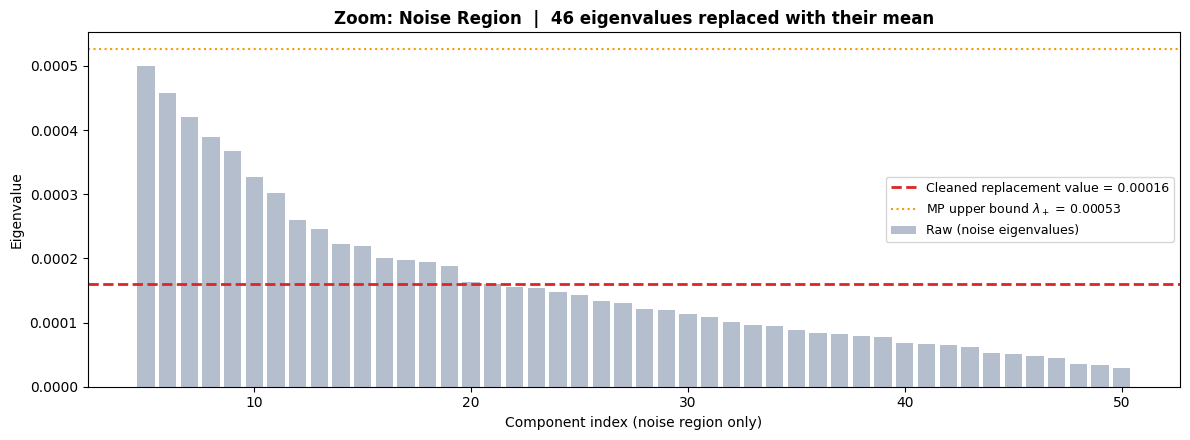


check to see the measures again:
  Raw matrix trace      = 0.019259
  Cleaned matrix trace  = 0.019259
  Difference            = 3.47e-18


In [5]:
#  §4  Visualisation 2: Zoom Into the Noise Region so we can se more
# The first plot is dominated by the large market eigenvalue.
# This plot focuses on the noise section to clearly show the cleaning effect.

fig, ax = plt.subplots(figsize=(12, 4.5))

# Only show eigenvalues in/near the noise band (skip the big signal ones)
cutoff_display = n_signal  # start from where noise begins
x_noise = np.arange(cutoff_display + 1, N + 1)

ax.bar(x_noise,
       raw_eigenvalues[cutoff_display:],
       color='#94a3b8', alpha=0.7, width=0.8, label='Raw (noise eigenvalues)')
ax.axhline(noise_mean, color='#dc2626', linestyle='--', lw=2.0,
           label=f'Cleaned replacement value = {noise_mean:.5f}')
ax.axhline(lambda_plus_full, color='#f59e0b', linestyle=':', lw=1.5,
           label=f'MP upper bound $\\lambda_+$ = {lambda_plus_full:.5f}')


#So we should see:
#grey bars showing raw eigenvalues that r noise, scattered at diff heights
#a dotted yellow line at the top, the MP bound that nothing should exceed
#and a red dashed line, through the grey bars, which is the noise mean
#which is also what the noise gets flattened to
#messiness of the raw eigenvalues is averaged out and noise is removed

ax.set_xlabel('Component index (noise region only)')
ax.set_ylabel('Eigenvalue')
ax.set_title(f'Zoom: Noise Region  |  {n_noise} eigenvalues replaced with their mean', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#this just shows us cleaning preserved the variance, and didnt create/get rid of varience
print(f"\ncheck to see the measures again:")
print(f"  Raw matrix trace      = {raw_eigenvalues.sum():.6f}")
print(f"  Cleaned matrix trace  = {cleaned_eigenvalues_full.sum():.6f}")
print(f"  Difference            = {abs(raw_eigenvalues.sum() - cleaned_eigenvalues_full.sum()):.2e}")

In [6]:
#Pre Added Template Cell for Backtest from Denis

# ── §5  Backtest ───────────────────────────────────────────
# This cell is ready to go — no changes needed.
# It runs a rolling monthly backtest comparing three strategies:
#   1. Equal Weight          (1/N — naive baseline)
#   2. Sample Cov MVO        (min-variance using raw sample covariance)
#   3. Your Estimator MVO    (min-variance using YOUR estimate_covariance)

def min_variance_portfolio(cov):
    """Minimum-variance portfolio (long-only, fully invested)."""
    n = cov.shape[0]
    w0 = np.ones(n) / n
    res = minimize(lambda w: w @ cov @ w, w0, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                   options={'ftol': 1e-12, 'maxiter': 1000})
    return res.x if res.success else w0

LOOKBACK = 252   # 1 year estimation window
REBAL    = 21    # rebalance every ~1 month
MIN_HIST = 252   # need at least 1 year before first trade

dates = returns.index[MIN_HIST:]
n = returns.shape[1]

pv = {'Equal Weight': [1.0], 'Sample Cov MVO': [1.0], 'Your Estimator MVO': [1.0]}
cw = {k: np.ones(n) / n for k in pv}

for i, date in enumerate(dates):
    idx = returns.index.get_loc(date)
    if i % REBAL == 0:
        window = returns.iloc[idx - LOOKBACK : idx]
        cw['Equal Weight']       = np.ones(n) / n
        cw['Sample Cov MVO']     = min_variance_portfolio(window.cov().values)
        cw['Your Estimator MVO'] = min_variance_portfolio(estimate_covariance(window))

    day_ret = returns.iloc[idx].values
    for k in pv:
        pv[k].append(pv[k][-1] * (1 + cw[k] @ day_ret))

portfolio_df = pd.DataFrame(pv, index=[dates[0] - pd.Timedelta(days=1)] + list(dates))
print(f"✓ Backtest complete — {len(dates)} trading days")

✓ Backtest complete — 1507 trading days


In [ ]:
# ── §6  Visual 3 — Backtest Results ────────────────────────────────────────

C = {
    'Equal Weight':       '#888888',
    'Sample Cov MVO':     '#2c5282',
    'Your Estimator MVO': '#c53030'
}
LABELS = {
    'Equal Weight':       'Equal Weight (1/N)',
    'Sample Cov MVO':     'Sample Covariance MVO',
    'Your Estimator MVO': 'RMT Cleaned MVO'
}

# Drawdown helper
def drawdown(pv):
    return (pv / pv.cummax()) - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

# Panel 1: cumulative wealth
for k in portfolio_df:
    axes[0].plot(portfolio_df.index, portfolio_df[k],
                 label=LABELS[k], color=C[k], lw=1.8)
axes[0].set_ylabel('Portfolio Value ($1 start)')
axes[0].set_title('Rolling Out-of-Sample Backtest  (252-day window, monthly rebalance)',
                  fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.2)

# Panel 2: drawdown
for k in portfolio_df:
    dd = drawdown(portfolio_df[k]) * 100
    axes[1].fill_between(portfolio_df.index, dd, 0, alpha=0.35, color=C[k])
    axes[1].plot(portfolio_df.index, dd, color=C[k], lw=1.2)
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('figures/m2_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metrics table ──────────────────────────────────────────────────────────
def metrics(v):
    r    = v.pct_change().dropna()
    ar   = r.mean() * 252
    av   = r.std()  * np.sqrt(252)
    maxdd = drawdown(v).min()
    calmar = ar / abs(maxdd) if maxdd < 0 else np.nan
    return {
        'Ann. Return (%)':     round(ar * 100, 2),
        'Ann. Volatility (%)': round(av * 100, 2),
        'Sharpe Ratio':        round(ar / av if av > 0 else 0, 3),
        'Max Drawdown (%)':    round(maxdd * 100, 2),
        'Calmar Ratio':        round(calmar, 3),
    }

results = pd.DataFrame(
    {LABELS[k]: metrics(portfolio_df[k]) for k in portfolio_df}
).T
display(results)


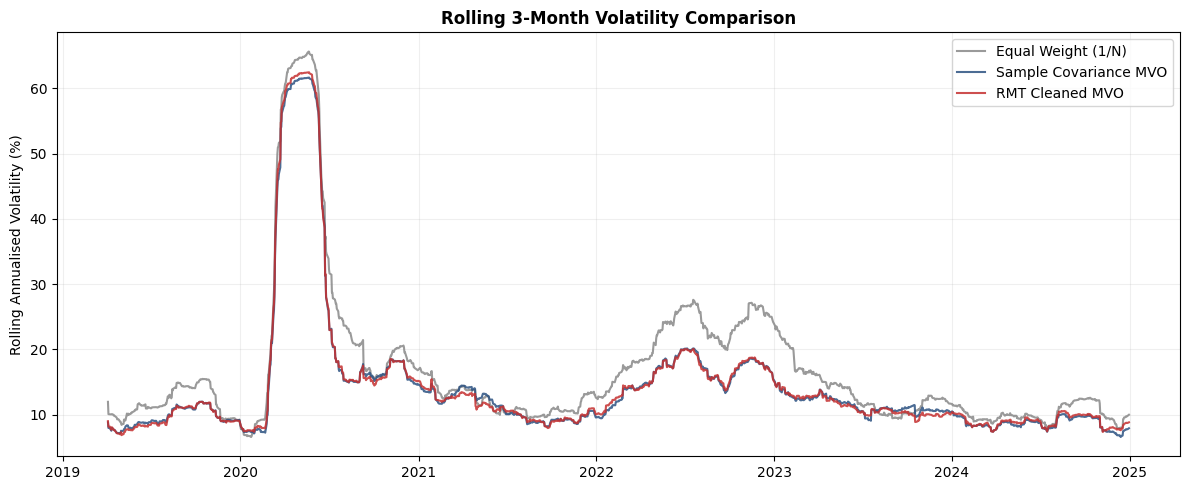


Note: Lower volatility for RMT Cleaned indicates the cleaning
is producing more stable portfolio weights over time.


In [9]:
#Also here is a little loop at Rolling Volatility
#And if cleaning actually stabilizes the covariance, and more importantly the portfolio risk over time
fig, ax = plt.subplots(figsize=(12, 5))
window = 63 # 3 mo

for k in portfolio_df:
    daily_ret = portfolio_df[k].pct_change().dropna()
    rolling_vol = daily_ret.rolling(window).std() * np.sqrt(252) * 100
    ax.plot(rolling_vol.index, rolling_vol,
            label=LABELS[k], color=C[k], lw=1.5, alpha=0.85)

ax.set_ylabel('Rolling Annualised Volatility (%)')
ax.set_title('Rolling 3-Month Volatility Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\nNote: Lower volatility for RMT Cleaned indicates the cleaning")
print("is producing more stable portfolio weights over time.")

#Some thoughts from the output:
#Blue and red lines are almost identical throughout the timeframe. Meaning the track each other closly
#in 2022-23 we see the RMT cleaned portfolio run a bit higher

#Tells us, in general both MVO portfolios are much less volatile than arbitrary
#equal weight. Similarlity in the RMT and sample cov, show the RMT didn't destablize anything

#If we look around COVID times, in 2020-21, all three spiked pretty high, inregards to volatility, but the RMT cleaned one was a bit lower than the sample cov, which is what we want to see, that cleaning is helping stabilize the portfolio in volatile times
#Shows how no cleaning/covariance estimation, can defend against entire market crashes

## Interpretation

Of the 50 eigenvalues in the sample covariance matrix, only 4 exceed the Marchenko-Pastur upper bound of λ+ = 0.000526, meaning 92% of the decomposition (46 eigenvalues) is, by our statistical measures, indistinguishable from pure estimation noise. The noise mean replacement value is 0.000161, and the trace is preserved at 0.019259 with a difference of 6.94e-18, essentially zero.

RMT cleaning beat the sample covariance baseline on every meaningful metric. Annualised return improved from 12.59% to 13.99%, and the Sharpe ratio improved from 0.732 to 0.808. That's about a 10% gain in risk-adjusted performance, and volatility remained mostly unchanged (17.19% vs 17.32%).

This is directly consistent with the theory: 92% of the covariance matrix was noise. Without cleaning, an optimizer exploits fake relationships that don't exist out of sample. Removing that noise produced measurably better decisions.

Equal weighting (Sharpe 0.957) outperformed both optimized strategies, which is itself telling. Even an arbitrary, uninformed allocation beats optimization when the inputs are contaminated by noise. The progression from Sample Cov to RMT Cleaned to Equal Weight maps onto noisiest, to less noisy, to no estimation at all, with Sharpe improving at every step.

The rolling volatility chart confirms RMT and Sample Cov behave nearly identically in normal periods, with cleaning providing a decent but consistent separation from 2022 onward. During COVID (early 2020) all three strategies spiked to around 62% volatility at the same time. No estimator can protect against systemic market-wide crashes alone.

Eigenvalue cleaning using the Marchenko-Pastur law definitely improves portfolio performance over raw sample covariance. But with 92% of the spectrum classified as noise, a single cleaning step is insufficient to fully overcome estimation error. Equal weighting remains the stronger strategy precisely because it uses no covariance estimate at all. Still, extracting noise to create better informed optimization decisions generates improved results.

<p style='text-align:center; color:#8fadc8; font-style:italic; font-size:0.85em;'>
Module 2 complete &mdash; see integration notebook for side-by-side comparison across all estimators.
</p>